In [1]:
import glob
import eigsep_observing.io as io
import eigsep_data.plot as edp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.gridspec import GridSpec
import os
from datetime import datetime, timezone
from zoneinfo import ZoneInfo
import numpy as np
from hera_filters.dspec import dpss_operator, fit_solution_matrix
import h5py
import json
import healpy as hp
from healpy.sphtfunc import Alm
from scipy.special import sph_harm

%matplotlib widget

In [2]:
def read_header(fname, keys=None):
    with h5py.File(fname, "r") as f:
                # header
        header_grp = f["header"]
        header = {k: v for k, v in header_grp.attrs.items()}
        for name, obj in header_grp.items():
            if isinstance(obj, h5py.Group):
                header[name] = {k: v for k, v in obj.attrs.items()}
            else:
                header[name] = io._read_dataset(obj)
        # metadata — like the header, this group can carry both
        # attrs (scalar metadata stored via _write_attr) and
        # datasets/subgroups (lists, dicts, arrays). Read both,
        # mirroring the header read above.
        metadata = {}
        if "metadata" in f:
            meta_grp = f["metadata"]
            for k, v in meta_grp.attrs.items():
                metadata[k] = v
            for name, obj in meta_grp.items():
                if isinstance(obj, h5py.Group):
                    metadata[name] = {k: v for k, v in obj.attrs.items()}
                else:
                    metadata[name] = io._read_dataset(obj)
    return header, metadata

mtn_tzone = ZoneInfo("America/Denver")

def unix_time_to_local(unix_times):
    local_times = np.array([datetime.fromtimestamp(ts, tz=timezone.utc).astimezone(mtn_tzone) for ts in unix_times])
    return local_times

dtype_r = np.float32
dtype_c = np.complex64

In [14]:
PATH = 'marjum-2026-07'
if True:
    meta_keys = set()
    hdr, meta = None, None
    files = sorted(glob.glob(os.path.join(PATH, '*.h5')))[-185:-150]
    times = np.zeros(len(files) * 240, dtype=np.float64)
    acc_cnt = np.zeros(len(files) * 240, dtype=np.int32)
    accel = np.zeros((len(files) * 240, 3), dtype=np.float32)
    lidar = np.zeros((len(files) * 240), dtype=np.float32)
    pot = np.zeros((len(files) * 240), dtype=np.float32)
    azm = np.zeros((len(files) * 240), dtype=np.float32)
    elm = np.zeros((len(files) * 240), dtype=np.float32)
    for cnt, f in enumerate(files):
        try:
            _hdr, _meta = read_header(f, {'times', 'acc_cnt'})
            meta_keys = meta_keys.union(_meta.keys())
            try:
                for i, imu in enumerate(_meta['imu_el']):
                    if imu is None:
                        continue
                    accel[240 * cnt + i, 0] = imu['accel_x']
                    accel[240 * cnt + i, 1] = imu['accel_y']
                    accel[240 * cnt + i, 2] = imu['accel_z']
            except(KeyError):
                pass
            try:
                for i, lid in enumerate(_meta['lidar']):
                    if lid is None:
                        continue
                    lidar[240 * cnt + i] = lid['distance_m']
            except(KeyError):
                pass
            try:
                for i, pt in enumerate(_meta['potmon']):
                    if pt is None:
                        continue
                    pot[240 * cnt + i] = pt['pot_az_angle']
            except(KeyError):
                pass
            try:
                for i, mt in enumerate(_meta['motor']):
                    if mt is None:
                        continue
                    azm[240 * cnt + i] = mt['az_pos']
                    elm[240 * cnt + i] = mt['el_pos']
            except(KeyError):
                pass
            times[240 * cnt:240 * cnt + _hdr['times'].size] = _hdr['times']
            acc_cnt[240 * cnt:240 * cnt + _hdr['acc_cnt'].size] = _hdr['acc_cnt']
            if hdr is None:
                hdr, meta = read_header(f)
        except(KeyError,OSError):
            print(f)
            pass

    valid = np.where(times > 0)
    local_times = unix_time_to_local(times)
    freqs = np.asarray(hdr['freqs'])

In [15]:
meta_keys

{'adc_stats',
 'imu_az',
 'imu_el',
 'lidar',
 'motor',
 'potmon',
 'rfswitch',
 'rfswitch_therm',
 'system_current',
 'tempctrl_lna',
 'tempctrl_load'}

In [16]:
#npz_file = 'all_ant_4.npz'
keys = {'0', '4', '04'}
ntimes = times.size
nfreqs = hdr['nchan']
if True:
    data = {k: np.empty((ntimes, nfreqs), dtype=dtype_r) if len(k) == 1 else np.empty((ntimes, nfreqs), dtype=dtype_c) for k in keys}
    #times = np.empty(ntimes, dtype=dtype_r)
    for i, f in enumerate(files):
        dat, hdr, meta = io.read_hdf5(f)
        nt = len(hdr['times'])
        times[240*i:240*i+nt] = hdr['times']
        for k in keys:
            data[k][240*i:240*i+nt] = dat[k]
        #i += nt
    #local_times = unix_time_to_local(times)
    #np.savez(npz_file, times=times[t_valid], local_times=local_times[t_valid], freqs=freqs, **{k: v[t_valid] for k,v in data.items()})

/tmp/ipykernel_190148/2786446361.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(4, 1, sharex=True)
/tmp/ipykernel_190148/2786446361.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


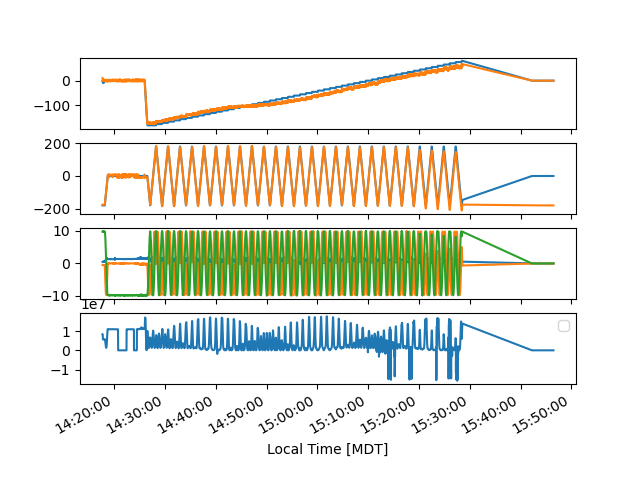

In [38]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(4, 1, sharex=True)
#ax[0].plot(local_times[valid], lidar[valid])
MOTOR_CAL = 180 / 1.13e4
azm_deg = MOTOR_CAL * azm
elm_deg = MOTOR_CAL * elm
accel_deg = np.unwrap(np.rad2deg(np.arctan2(np.sign(accel[:,1]) * np.linalg.norm(accel[:,:2], axis=1),-accel[:, 2])), period=360)
ax[0].plot(local_times[valid], azm_deg[valid])
ax[0].plot(local_times[valid], pot[valid])
ax[1].plot(local_times[valid], elm_deg[valid])
ax[1].plot(local_times[valid], accel_deg[valid])
ax[2].plot(local_times[valid], accel[valid], label=['x','y','z'])
ch = 600
ax[3].plot(local_times[valid], data['4'][:, ch] - 0.5 * (data['4'][:, ch-1] + data['4'][:, ch+1]))
#ch = 608
#ax[3].plot(local_times[valid], 20*(data['4'][:, ch] - 0.5 * (data['4'][:, ch-1] + data['4'][:, ch+1])))
#plt.title('IMU (el) Acceleration')
#ax[2].set_ylabel('Acceleration [$m/s^2$]')
date_form = mdates.DateFormatter("%H:%M:%S", tz=local_times[0].tzinfo)
ax[3].xaxis.set_major_formatter(date_form)
fig.autofmt_xdate()
ax[3].set_xlabel('Local Time [MDT]')
plt.legend()

Text(0.5, 1.0, 'Beam Map @  130.859 MHz')

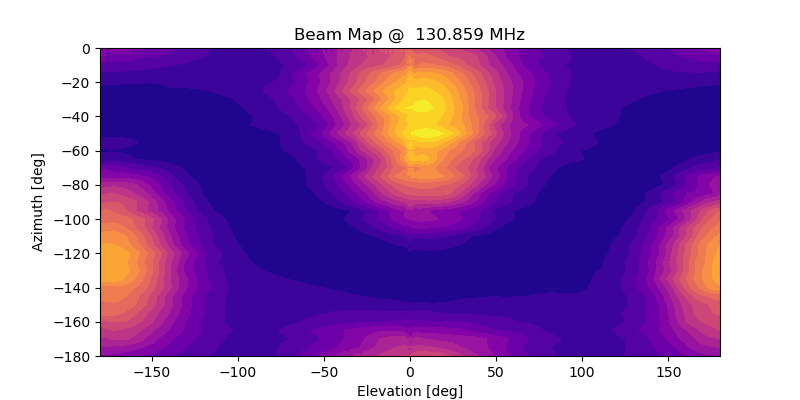

In [89]:
plt.figure(figsize=(8, 4))
ch = 600 - 4 * 16
d = data['4'][:, ch] - 0.5 * (data['4'][:, ch-1] + data['4'][:, ch+1])
valid2 = np.where(d > 1e4, valid, 0)
#plt.scatter(azm_deg[valid2], elm_deg[valid2], c=d[valid2], s=24, cmap='plasma')
#plt.tricontourf(azm_deg[valid2].flatten(), elm_deg[valid2].flatten(), d[valid2].flatten(), levels=20, cmap='plasma')
plt.tricontourf(elm_deg[valid2].flatten(), azm_deg[valid2].flatten(), d[valid2].flatten(), levels=20, cmap='plasma')
plt.xlim(-180, 180)
plt.ylim(-180, 180)
plt.xlabel('Elevation [deg]')
plt.ylabel('Azimuth [deg]')
plt.ylim(-180, 0)
plt.title(f'Beam Map @ {freqs[ch]: 4.3f} MHz')

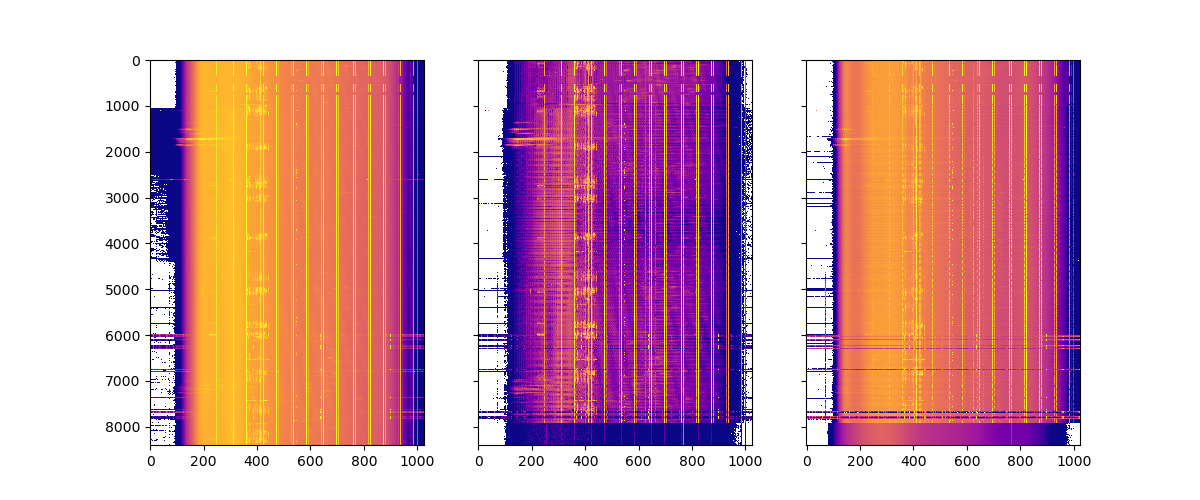

In [68]:
fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(12, 5))
kwargs = dict(origin='upper', vmin=3, vmax=7, interpolation='nearest')
edp.waterfall(data[ '0'], ax=axes[0], **kwargs)
edp.waterfall(data['04'], ax=axes[1], **kwargs)
edp.waterfall(data[ '4'], ax=axes[2], **kwargs)